In [1]:
import numpy as np
import matplotlib.pyplot as plt

%matplotlib widget

In [13]:
def S21(S, X):
    R = (S+4*X**2)/(1+4*X**2)
    I = 2*X*(1-S)/(1+4*X**2)
    return R + 1j*I

def abs_S21_bisi(S, X):
    return 1-(1-S**2)/(1+4*X**2)

def ang_S21_bisi(X):
    return np.arctan(4*X/(X**2-1))

In [32]:
dX = 2
X = np.linspace(-10, 10, 1000)
X1 = X+dX/2
X2 = X-dX/2
S = 10**(-2)
Z1 = S21(S, X1)
Z2 = S21(S, X2)
Z = Z1*Z2
mag = np.abs(Z)
phase = np.angle(Z)
grad_phase = np.gradient(phase, X)

phase_bisigello = np.arctan(4*X/(X**2-1))
grad_bisigello = 4*(4*X**2+1)/(16*X**2+(4*X**2-1)**2)
mag_bisigello = (S**2+4*X**2)/(1+4*X**2)
dphase_dX = np.gradient(phase_bisigello, X)

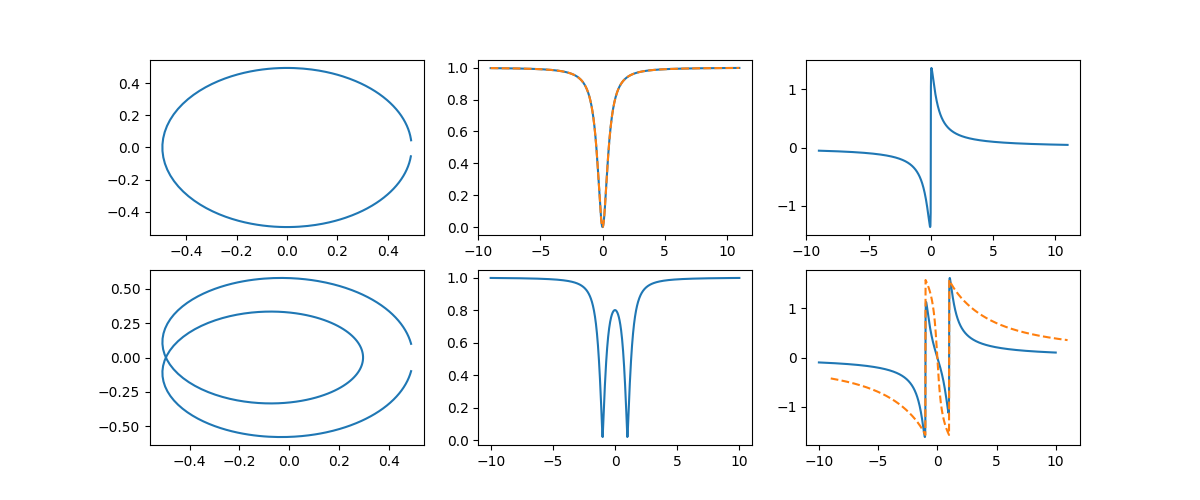

In [33]:
fig, ax = plt.subplots(2, 3, figsize=(12, 5))
ax[0, 0].plot(Z1.real-(1+S)/2, Z1.imag)
ax[0, 1].plot(X1, np.abs(Z1)**2)
ax[0, 1].plot(X1, abs_S21_bisi(S, X1), ls='--')
ax[0, 2].plot(X1, np.angle(Z1))
ax[1, 0].plot(Z.real-(1+S)/2, Z.imag)
ax[1, 1].plot(X, mag)
ax[1, 2].plot(X, phase)
ax[1, 2].plot(X1, ang_S21_bisi(X1), ls='--')
# ax[1, 2].plot(X, phase, label='phase')
# ax[1, 2].plot(X, phase_bisigello, label='bisi')
# ax[1, 2].plot(X, grad_phase, label='grad phase')
# ax[1, 2].plot(X, grad_bisigello, label='grad bisi')
# ax[1, 2].plot(X, -dphase_dX, label='dphasedx')
# ax[1, 2].legend()


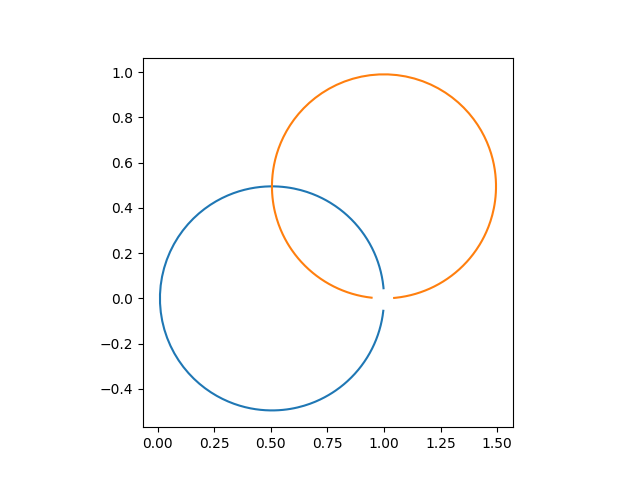

In [45]:
fig, ax = plt.subplots()
ax.plot(Z1.real, Z1.imag)
ax.plot(((Z1-1)*-1j+1).real, ((Z1-1)*-1j+1).imag)
ax.set_aspect('equal')

In [49]:
np.rad2deg(np.arctan(2*5e4*2e-4))

87.13759477388825

84.28940686250037


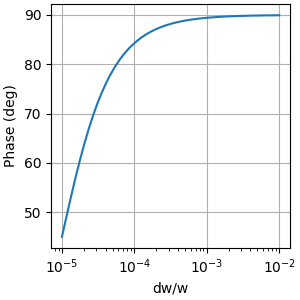

In [57]:
fig, ax = plt.subplots(constrained_layout=True, figsize=(3,3))
dw_w = np.logspace(-5, -2)
phi = np.rad2deg(np.arctan(2*5e4*dw_w))
ax.semilogx(dw_w, phi)
ax.set_xlabel('dw/w')
ax.set_ylabel('Phase (deg)')
print(np.rad2deg(np.arctan(2*5e4*1e-4)))
ax.grid()